In [18]:
import pandas as pd
import plotly.graph_objects as go

In [19]:
bacteroides_fecal_data = [
    ['Bacteroides fragilis', 'Vaginal delivery', 'Shared', 5],
    ['Bacteroides fragilis', 'Vaginal delivery', 'Not Shared', 3],
    ['Bacteroides fragilis', 'C-section', 'Not Shared', 2], 
    
    ['Bacteroides caccae', 'Vaginal delivery', 'Shared', 2],
    ['Bacteroides caccae', 'Vaginal delivery', 'Not Shared', 10],
    ['Bacteroides caccae', 'C-section', 'Not Shared', 4], 
    
    ['Bacteroides stercoris', 'Vaginal delivery', 'Shared', 2],
    ['Bacteroides stercoris', 'Vaginal delivery', 'Not Shared', 16],
    ['Bacteroides stercoris', 'C-section', 'Not Shared', 6], 
    
    ['Bacteroides thetaiotaomicron', 'Vaginal delivery', 'Shared', 6],
    ['Bacteroides thetaiotaomicron', 'Vaginal delivery', 'Not Shared', 12],
    ['Bacteroides thetaiotaomicron', 'C-section', 'Not Shared', 6], 
    
    ['Bacteroides uniformis', 'Vaginal delivery', 'Shared', 8],
    ['Bacteroides uniformis', 'Vaginal delivery', 'Not Shared', 20],
    ['Bacteroides uniformis', 'C-section', 'Shared', 1],
    ['Bacteroides uniformis', 'C-section', 'Not Shared', 4], 
]

bacteroides_fecal_df = pd.DataFrame(bacteroides_fecal_data, columns=['Species', 'Delivery Mode', 'Shared Status', 'Count'])


In [20]:
bifido_fecal_data = [
    ['Bifidobacterium dentium', 'Vaginal delivery', 'Not Shared', 2],
    ['Bifidobacterium dentium', 'C-section', 'Shared', 1], 
    
    ['Bifidobacterium longum subsp. longum', 'Vaginal delivery', 'Shared', 4],
    ['Bifidobacterium longum subsp. longum', 'Vaginal delivery', 'Not Shared', 4],
    ['Bifidobacterium longum subsp. longum', 'C-section', 'Shared', 1], 
    
    ['Bifidobacterium pseudocatenulatum', 'Vaginal delivery', 'Shared', 5],
    ['Bifidobacterium pseudocatenulatum', 'Vaginal delivery', 'Not Shared', 3],
    ['Bifidobacterium pseudocatenulatum', 'C-section', 'Not Shared', 1], 
    
    ['Bifidobacterium bifidum', 'Vaginal delivery', 'Shared', 5],
    ['Bifidobacterium bifidum', 'Vaginal delivery', 'Not Shared', 4],
    ['Bifidobacterium bifidum', 'C-section', 'Shared', 1],
    ['Bifidobacterium bifidum', 'C-section', 'Not Shared', 2], 

    ['Bifidobacterium adolescentis', 'Vaginal delivery', 'Shared', 5],
    ['Bifidobacterium adolescentis', 'Vaginal delivery', 'Not Shared', 22],
    ['Bifidobacterium adolescentis', 'C-section', 'Not Shared', 8], 
]

bifido_fecal_df = pd.DataFrame(bifido_fecal_data, columns=['Species', 'Delivery Mode', 'Shared Status', 'Count'])


In [21]:
vaginal_data = [
    ['Bifidobacterium dentium', 'Vaginal delivery', 'Shared', 2], 

    ['Bifidobacterium breve', 'Vaginal delivery', 'Shared', 1],
    ['Bifidobacterium breve', 'Vaginal delivery', 'Not Shared', 1],

    ['Bifidobacterium longum subsp. infantis', 'Vaginal delivery', 'Shared', 1],
    
    ['Faecalibacterium prausnitzii', 'Vaginal delivery', 'Not Shared', 1],
    
    ['Lactobacillus iners', 'Vaginal delivery', 'Not Shared', 18],
    ['Lactobacillus iners', 'C-section', 'Not Shared', 7],

    ['Lactobacillus crispatus', 'Vaginal delivery', 'Not Shared', 22],
    ['Lactobacillus crispatus', 'C-section', 'Not Shared', 5],
]

vaginal_df = pd.DataFrame(vaginal_data, columns=['Species', 'Delivery Mode', 'Shared Status', 'Count'])


In [22]:
def create_publication_sankey(df):
    """
    Generates a print-ready (6x4 inch, 300 DPI) Sankey diagram for flow analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Must contain exact columns: ['Species', 'Delivery Mode', 'Shared Status', 'Count']
        
    Returns:
    --------
    plotly.graph_objs._figure.Figure
        The Plotly figure object.
    """
    
    # 1. VALIDATE INPUT AND COPY
    expected_cols = ['Species', 'Delivery Mode', 'Shared Status', 'Count']
    if not all(col in df.columns for col in expected_cols):
        raise ValueError(f"DataFrame must contain columns: {expected_cols}")
        
    df = df.copy()

    # 2. EXTRACT NODES & CREATE BRANCHING STRUCTURE
    df['Middle Node'] = df['Species'].astype(str) + ' - ' + df['Delivery Mode'].astype(str)

    species_nodes = df['Species'].unique().tolist()
    middle_nodes = df['Middle Node'].unique().tolist()
    status_nodes = df['Shared Status'].unique().tolist()

    all_nodes = species_nodes + middle_nodes + status_nodes
    node_dict = {node: i for i, node in enumerate(all_nodes)}

    # 3. CALCULATE TOTALS FOR LABELS
    # Convert to Categorical to safely use observed=True and silence Pandas warnings
    df['Species'] = pd.Categorical(df['Species']) 
    species_counts = df.groupby('Species', observed=True)['Count'].sum().to_dict()
    middle_counts = df.groupby('Middle Node', observed=True)['Count'].sum().to_dict()

    # 4. FORMAT LABELS (Species get text+count, middle get count, status stay blank)
    display_labels = (
        [f"<i>{n}</i> (n={species_counts[n]})" for n in species_nodes] + 
        [str(middle_counts[n]) for n in middle_nodes] + 
        [""] * len(status_nodes)
    )


    # 5. DEFINE NODE COLORS & BORDERS
    # Species boxes are a solid dark gray
    color_species = ["#666666"] * len(species_nodes) 

    # Delivery Mode Colors
    mode_map = {'Vaginal delivery': '#2ca02c', 'C-section': '#ff7f0e'}
    # Fallback to gray if a new mode appears in future datasets
    color_modes = [mode_map.get(n.split(' - ')[1], '#999999') for n in middle_nodes]

    # Shared Status Colors
    status_map = {'Shared': '#646464', 'Not Shared': '#c3c3c3'}
    color_status = [status_map.get(n, '#999999') for n in status_nodes]

    # Combine colors and apply black borders to all nodes
    node_colors = color_species + color_modes + color_status
    line_colors = ['black'] * len(all_nodes) 
    node_thickness = 25 

    # 6. PREPARE LINKS (All Uniform Gray)
    df_t1 = df.groupby(['Species', 'Middle Node'], observed=True)['Count'].sum().reset_index()
    source1 = df_t1['Species'].map(node_dict).tolist()
    target1 = df_t1['Middle Node'].map(node_dict).tolist()
    value1 = df_t1['Count'].tolist()

    df_t2 = df.groupby(['Species', 'Middle Node', 'Shared Status'], observed=True)['Count'].sum().reset_index()
    source2 = df_t2['Middle Node'].map(node_dict).tolist()
    target2 = df_t2['Shared Status'].map(node_dict).tolist()
    value2 = df_t2['Count'].tolist()

    sources = source1 + source2
    targets = target1 + target2
    values = value1 + value2

    # 7. BUILD THE FIGURE
    fig = go.Figure()

    fig.add_trace(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,          
            thickness=node_thickness,    
            line=dict(color=line_colors, width=0.5), 
            label=display_labels, 
            color=node_colors 
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color='rgba(200, 200, 200, 0.4)' 
        )
    ))

    # 8. ADD THE CUSTOM LEGEND
    for mode, color in mode_map.items():
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=14, color=color, symbol='square', line=dict(color='black', width=1)),
            name=mode, legendgroup="Modes", legendgrouptitle_text="<b>Delivery mode</b>"
        ))

    for status, color in status_map.items():
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=14, color=color, symbol='square', line=dict(color='black', width=1)),
            name=status, legendgroup="Status", legendgrouptitle_text="<br><b>Strain sharing</b>"
        ))

    # 9. FORMAT FOR PUBLICATION 
    fig.update_layout(
        font_size=14,
        font_family="Arial",
        plot_bgcolor='white',
        paper_bgcolor='white',
        width=900,  
        height=600, 
        showlegend=True,
        legend=dict(yanchor="top", y=1, xanchor="left", x=1.02),
        margin=dict(t=50, l=40, r=200, b=40), 
        xaxis=dict(showgrid=False, zeroline=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False, visible=False),
        annotations=[
            # dict(x=0.01, y=1.05, xref='paper', yref='paper', text='<b>Species</b>', showarrow=False, font=dict(size=16)),
            # dict(x=0.50, y=1.05, xref='paper', yref='paper', text='<b>Delivery Mode</b>', showarrow=False, font=dict(size=16)),
            # dict(x=1.00, y=1.05, xref='paper', yref='paper', text='<b>Shared Status</b>', showarrow=False, font=dict(size=16))
        ] 
    )


    return fig

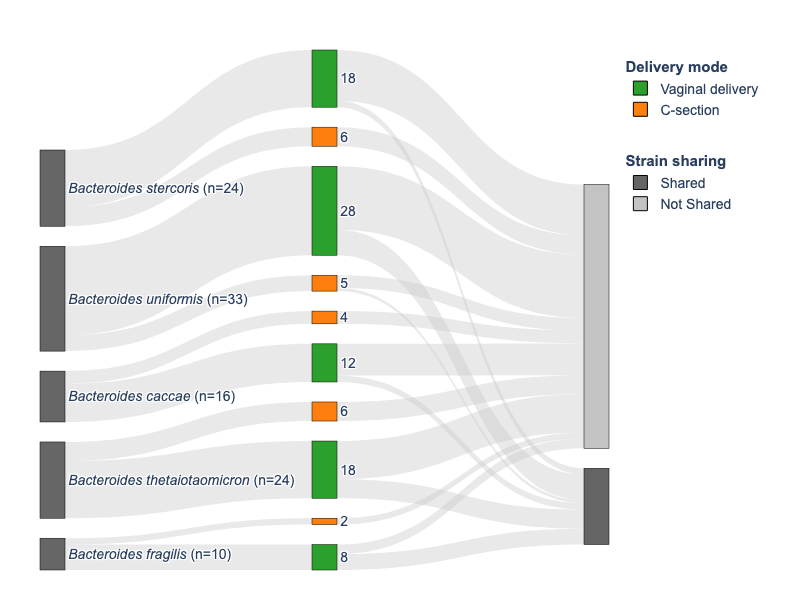

In [26]:
bacteroides_fecal_fig = create_publication_sankey(bacteroides_fecal_df)
bacteroides_fecal_fig.show()
bacteroides_fecal_fig.write_image("bacteroides_fecal_sankey.pdf", width=900, height=600, scale=2)

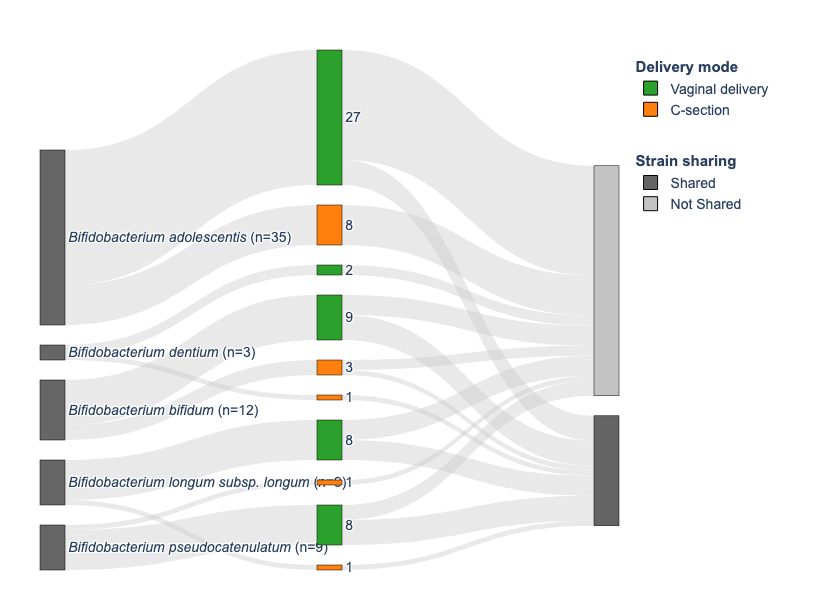

In [27]:
bifido_fecal_fig = create_publication_sankey(bifido_fecal_df)
bifido_fecal_fig.show()
bifido_fecal_fig.write_image("bifido_fecal_sankey.pdf", width=900, height=600, scale=2)

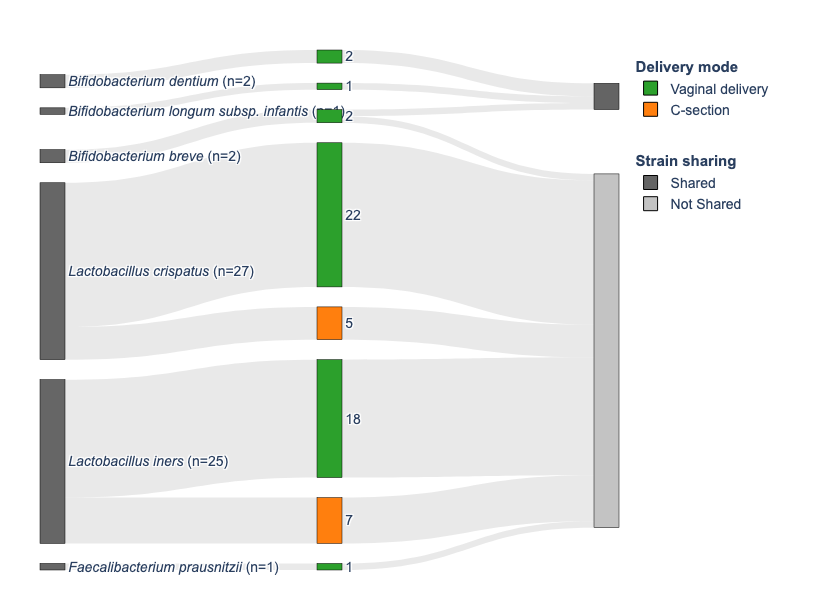

In [28]:
vaginal_fig = create_publication_sankey(vaginal_df)
vaginal_fig.show()
vaginal_fig.write_image("vaginal_sankey.pdf", width=900, height=600, scale=2)